In [352]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split  # Split data
from sklearn.model_selection import GridSearchCV      # Hyperparameter tuning
from sklearn.pipeline import Pipeline                 # Chain steps together
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer # Apply different transforms to different columns
from sklearn.metrics import accuracy_score, classification_report # Classification
from sklearn.metrics import mean_squared_error, r2_score         # Regression
from sklearn.metrics import confusion_matrix                      # Error Analysis

In [353]:
offenders_df = pd.read_csv('/Users/mohitacharya/NYC DATA/NYPD_Shooting_Offenders_20260218.csv')
offenders_df.head()

,INCIDENT_KEY,PERP_ID,PERP_AGE_GROUP,PERP_SEX,PERP_RACE
0,9953248,9953248-9042,18-24,MALE,BLACK
1,10137418,10137418-9127,25-44,MALE,BLACK
2,10137428,10137428-9147,UNKNOWN,UNKNOWN,UNKNOWN
3,10187494,10187494-9181,UNKNOWN,MALE,BLACK
4,10187494,10187494-9195,UNKNOWN,MALE,BLACK


In [354]:
victims_df = pd.read_csv('/Users/mohitacharya/NYC DATA/NYPD_Shooting_Victims_20260219.csv')
victims_df.head()

,INCIDENT_KEY,VICTIM_ID,VICTIM_AGE_GROUP,VICTIM_SEX,VICTIM_RACE,STAT_MURDER_FLG
0,299453927,299453927-1,25-44,MALE,BLACK,N
1,212336415,212336415-1,18-24,MALE,BLACK,N
2,280768895,280768895-1,25-44,MALE,BLACK,N
3,141824677,141824677-27687,25-44,MALE,BLACK HISPANIC,N
4,270079203,270079203-1,45-64,MALE,BLACK,Y


In [355]:
shootings_df = pd.read_csv('/Users/mohitacharya/NYC DATA/NYPD_Shootings_20260219.csv')
shootings_df.head()

,INCIDENT_KEY,OCCUR_DATE,OCCUR_TIME,BORO,LOC_OF_OCCUR_DESC,PRECINCT,JURISDICTION_CODE,LOC_CLASSFCTN_DESC,LOCATION_DESC,X_COORD_CD,Y_COORD_CD,Latitude,Longitude
0,297623042,12/06/2024,13:06:00,MANHATTAN,OUTSIDE,1,0.0,STREET,NaN,983437,201643,40.720149,-74.002931
1,73794477,07/21/2010,01:32:00,MANHATTAN,OUTSIDE,1,0.0,STREET,BAR/NIGHT CLUB,982761,204594,40.728241,-74.005370
2,242784290,03/28/2022,22:18:00,MANHATTAN,OUTSIDE,5,0.0,STREET,MULTI DWELL - APT BUILD,984732,200728,40.717629,-73.998260
3,24449553,09/23/2006,00:02:00,MANHATTAN,OUTSIDE,5,0.0,STREET,NaN,986929,202081,40.721343,-73.990335
4,64318199,08/02/2009,01:44:00,MANHATTAN,OUTSIDE,5,2.0,HOUSING,MULTI DWELL - PUBLIC HOUS,986577,200423,40.716801,-73.991606


In [356]:
offenders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18750 entries, 0 to 18749
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   INCIDENT_KEY    18750 non-null  int64 
 1   PERP_ID         18750 non-null  object
 2   PERP_AGE_GROUP  18720 non-null  object
 3   PERP_SEX        18750 non-null  object
 4   PERP_RACE       18750 non-null  object
dtypes: int64(1), object(4)
memory usage: 732.6+ KB


In [357]:
shootings_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23988 entries, 0 to 23987
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   INCIDENT_KEY        23988 non-null  int64  
 1   OCCUR_DATE          23988 non-null  object 
 2   OCCUR_TIME          23988 non-null  object 
 3   BORO                23988 non-null  object 
 4   LOC_OF_OCCUR_DESC   23988 non-null  object 
 5   PRECINCT            23988 non-null  int64  
 6   JURISDICTION_CODE   23986 non-null  float64
 7   LOC_CLASSFCTN_DESC  23956 non-null  object 
 8   LOCATION_DESC       9644 non-null   object 
 9   X_COORD_CD          23988 non-null  int64  
 10  Y_COORD_CD          23988 non-null  int64  
 11  Latitude            23855 non-null  float64
 12  Longitude           23855 non-null  float64
dtypes: float64(3), int64(4), object(6)
memory usage: 2.4+ MB


In [358]:
victims_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28748 entries, 0 to 28747
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   INCIDENT_KEY      28748 non-null  int64 
 1   VICTIM_ID         28747 non-null  object
 2   VICTIM_AGE_GROUP  28747 non-null  object
 3   VICTIM_SEX        28747 non-null  object
 4   VICTIM_RACE       28747 non-null  object
 5   STAT_MURDER_FLG   28747 non-null  object
dtypes: int64(1), object(5)
memory usage: 1.3+ MB


In [359]:
shootings_df.head(10)

,INCIDENT_KEY,OCCUR_DATE,OCCUR_TIME,BORO,LOC_OF_OCCUR_DESC,PRECINCT,JURISDICTION_CODE,LOC_CLASSFCTN_DESC,LOCATION_DESC,X_COORD_CD,Y_COORD_CD,Latitude,Longitude
0,297623042,12/06/2024,13:06:00,MANHATTAN,OUTSIDE,1,0.0,STREET,NaN,983437,201643,40.720149,-74.002931
1,73794477,07/21/2010,01:32:00,MANHATTAN,OUTSIDE,1,0.0,STREET,BAR/NIGHT CLUB,982761,204594,40.728241,-74.005370
2,242784290,03/28/2022,22:18:00,MANHATTAN,OUTSIDE,5,0.0,STREET,MULTI DWELL - APT BUILD,984732,200728,40.717629,-73.998260
3,24449553,09/23/2006,00:02:00,MANHATTAN,OUTSIDE,5,0.0,STREET,NaN,986929,202081,40.721343,-73.990335
4,64318199,08/02/2009,01:44:00,MANHATTAN,OUTSIDE,5,2.0,HOUSING,MULTI DWELL - PUBLIC HOUS,986577,200423,40.716801,-73.991606
5,11118235,04/26/2006,21:05:00,MANHATTAN,OUTSIDE,6,0.0,STREET,NaN,982301,204919,40.729142,-74.007033
6,235033374,10/15/2021,20:30:00,MANHATTAN,OUTSIDE,7,0.0,STREET,NaN,987969,200865,40.718004,-73.986584
7,52144006,10/10/2008,01:38:00,MANHATTAN,OUTSIDE,7,2.0,HOUSING,MULTI DWELL - PUBLIC HOUS,989248,198472,40.711446,-73.981970
8,37401695,01/01/2008,05:12:00,MANHATTAN,OUTSIDE,7,2.0,HOUSING,MULTI DWELL - PUBLIC HOUS,989138,199179,40.713385,-73.982369
9,16631507,05/31/2006,21:16:00,MANHATTAN,OUTSIDE,7,2.0,HOUSING,MULTI DWELL - APT BUILD,989248,198472,40.711446,-73.981970


**TOTAL INCIDENTS IN EACH BOROUGH***

In [360]:
# Brooklyn has the highest shooting incidents; 9677, followed by The Bronx; 6925 and Staten Island as the lowest; 671. 
shootings_df['BORO'].value_counts()

BORO
BROOKLYN         9677
BRONX            6925
QUEENS           3570
MANHATTAN        3145
STATEN ISLAND     671
Name: count, dtype: int64

***INCIDENT LOCATION - (LOCATION_DESC)***

*Splitting the OCCUR_DATE to Year and Month. Doing this will help us know the years and months which had the most and least incidents occured*

In [361]:
shootings_df

,INCIDENT_KEY,OCCUR_DATE,OCCUR_TIME,BORO,LOC_OF_OCCUR_DESC,PRECINCT,JURISDICTION_CODE,LOC_CLASSFCTN_DESC,LOCATION_DESC,X_COORD_CD,Y_COORD_CD,Latitude,Longitude
0,297623042,12/06/2024,13:06:00,MANHATTAN,OUTSIDE,1,0.0,STREET,NaN,983437,201643,40.720149,-74.002931
1,73794477,07/21/2010,01:32:00,MANHATTAN,OUTSIDE,1,0.0,STREET,BAR/NIGHT CLUB,982761,204594,40.728241,-74.005370
2,242784290,03/28/2022,22:18:00,MANHATTAN,OUTSIDE,5,0.0,STREET,MULTI DWELL - APT BUILD,984732,200728,40.717629,-73.998260
3,24449553,09/23/2006,00:02:00,MANHATTAN,OUTSIDE,5,0.0,STREET,NaN,986929,202081,40.721343,-73.990335
4,64318199,08/02/2009,01:44:00,MANHATTAN,OUTSIDE,5,2.0,HOUSING,MULTI DWELL - PUBLIC HOUS,986577,200423,40.716801,-73.991606
...,...,...,...,...,...,...,...,...,...,...,...,...,...
23983,233080844,09/02/2021,22:50:00,STATEN ISLAND,OUTSIDE,122,0.0,STREET,NaN,956215,153014,40.586620,-74.100935
23984,271104892,07/10/2023,18:48:00,STATEN ISLAND,INSIDE,123,0.0,OTHER,HOSPITAL,929510,127539,40.516572,-74.196874
23985,29155994,05/21/2007,14:08:00,STATEN ISLAND,OUTSIDE,123,0.0,STREET,MULTI DWELL - APT BUILD,935998,137296,40.543399,-74.173610
23986,78817501,05/17/2011,12:32:00,STATEN ISLAND,INSIDE,123,0.0,DWELLING,PVT HOUSE,932461,134246,40.535009,-74.186313


In [362]:
# Splitting the OCCUR DATE using the split method using the delimiter as "/"
shooting_month_year = shootings_df['OCCUR_DATE'].str.split("/", expand= True)


In [363]:
# Renaming the first and third column as "month" and "year" respectively
shooting_month_year = shooting_month_year.rename(columns = {0 : "month", 2: 'year'})

In [364]:
# Dropping the day column as we only need the month and year for the analysis
shooting_month_year = shooting_month_year.drop(axis = None, index = None, columns = 1)
shooting_month_year

,month,year
0,12,2024
1,07,2010
2,03,2022
3,09,2006
4,08,2009
...,...,...
23983,09,2021
23984,07,2023
23985,05,2007
23986,05,2011


In [365]:
# Concatenating the shooting_df and shooting_month_year dataframe into shooting_final dataframe. 
shooting_final = pd.concat([shootings_df, shooting_month_year], axis = 1)

In [366]:
shooting_final

,INCIDENT_KEY,OCCUR_DATE,OCCUR_TIME,BORO,LOC_OF_OCCUR_DESC,PRECINCT,JURISDICTION_CODE,LOC_CLASSFCTN_DESC,LOCATION_DESC,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,month,year
0,297623042,12/06/2024,13:06:00,MANHATTAN,OUTSIDE,1,0.0,STREET,NaN,983437,201643,40.720149,-74.002931,12,2024
1,73794477,07/21/2010,01:32:00,MANHATTAN,OUTSIDE,1,0.0,STREET,BAR/NIGHT CLUB,982761,204594,40.728241,-74.005370,07,2010
2,242784290,03/28/2022,22:18:00,MANHATTAN,OUTSIDE,5,0.0,STREET,MULTI DWELL - APT BUILD,984732,200728,40.717629,-73.998260,03,2022
3,24449553,09/23/2006,00:02:00,MANHATTAN,OUTSIDE,5,0.0,STREET,NaN,986929,202081,40.721343,-73.990335,09,2006
4,64318199,08/02/2009,01:44:00,MANHATTAN,OUTSIDE,5,2.0,HOUSING,MULTI DWELL - PUBLIC HOUS,986577,200423,40.716801,-73.991606,08,2009
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23983,233080844,09/02/2021,22:50:00,STATEN ISLAND,OUTSIDE,122,0.0,STREET,NaN,956215,153014,40.586620,-74.100935,09,2021
23984,271104892,07/10/2023,18:48:00,STATEN ISLAND,INSIDE,123,0.0,OTHER,HOSPITAL,929510,127539,40.516572,-74.196874,07,2023
23985,29155994,05/21/2007,14:08:00,STATEN ISLAND,OUTSIDE,123,0.0,STREET,MULTI DWELL - APT BUILD,935998,137296,40.543399,-74.173610,05,2007
23986,78817501,05/17/2011,12:32:00,STATEN ISLAND,INSIDE,123,0.0,DWELLING,PVT HOUSE,932461,134246,40.535009,-74.186313,05,2011


In [367]:
# Dropping the 'OCCUR DATE' as we had added the month and year while contatenating. 
shooting_final = shooting_final.drop(axis = None, index = None, columns = 'OCCUR_DATE')


In [368]:
shooting_final

,INCIDENT_KEY,OCCUR_TIME,BORO,LOC_OF_OCCUR_DESC,PRECINCT,JURISDICTION_CODE,LOC_CLASSFCTN_DESC,LOCATION_DESC,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,month,year
0,297623042,13:06:00,MANHATTAN,OUTSIDE,1,0.0,STREET,NaN,983437,201643,40.720149,-74.002931,12,2024
1,73794477,01:32:00,MANHATTAN,OUTSIDE,1,0.0,STREET,BAR/NIGHT CLUB,982761,204594,40.728241,-74.005370,07,2010
2,242784290,22:18:00,MANHATTAN,OUTSIDE,5,0.0,STREET,MULTI DWELL - APT BUILD,984732,200728,40.717629,-73.998260,03,2022
3,24449553,00:02:00,MANHATTAN,OUTSIDE,5,0.0,STREET,NaN,986929,202081,40.721343,-73.990335,09,2006
4,64318199,01:44:00,MANHATTAN,OUTSIDE,5,2.0,HOUSING,MULTI DWELL - PUBLIC HOUS,986577,200423,40.716801,-73.991606,08,2009
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23983,233080844,22:50:00,STATEN ISLAND,OUTSIDE,122,0.0,STREET,NaN,956215,153014,40.586620,-74.100935,09,2021
23984,271104892,18:48:00,STATEN ISLAND,INSIDE,123,0.0,OTHER,HOSPITAL,929510,127539,40.516572,-74.196874,07,2023
23985,29155994,14:08:00,STATEN ISLAND,OUTSIDE,123,0.0,STREET,MULTI DWELL - APT BUILD,935998,137296,40.543399,-74.173610,05,2007
23986,78817501,12:32:00,STATEN ISLAND,INSIDE,123,0.0,DWELLING,PVT HOUSE,932461,134246,40.535009,-74.186313,05,2011


In [369]:
# Here, we can see that the highest number of incidents recorded was in 2006 followed by 2021
shooting_final['year'].value_counts().sort_values(ascending = False)

year
2006    1566
2021    1562
2020    1532
2008    1520
2011    1510
2010    1473
2007    1442
2009    1420
2012    1373
2022    1294
2014    1172
2015    1138
2013    1103
2016     997
2023     974
2024     904
2017     789
2019     777
2018     754
2025     688
Name: count, dtype: int64

In [370]:
shooting_final['year'] = pd.to_numeric(shooting_final['year'])

In [371]:
shooting_final.dtypes

INCIDENT_KEY            int64
OCCUR_TIME             object
BORO                   object
LOC_OF_OCCUR_DESC      object
PRECINCT                int64
JURISDICTION_CODE     float64
LOC_CLASSFCTN_DESC     object
LOCATION_DESC          object
X_COORD_CD              int64
Y_COORD_CD              int64
Latitude              float64
Longitude             float64
month                  object
year                    int64
dtype: object

In [372]:
shooting_final['month'] = pd.to_numeric(shooting_final['month'])

In [373]:
shooting_final.head(10)

,INCIDENT_KEY,OCCUR_TIME,BORO,LOC_OF_OCCUR_DESC,PRECINCT,JURISDICTION_CODE,LOC_CLASSFCTN_DESC,LOCATION_DESC,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,month,year
0,297623042,13:06:00,MANHATTAN,OUTSIDE,1,0.0,STREET,NaN,983437,201643,40.720149,-74.002931,12,2024
1,73794477,01:32:00,MANHATTAN,OUTSIDE,1,0.0,STREET,BAR/NIGHT CLUB,982761,204594,40.728241,-74.005370,7,2010
2,242784290,22:18:00,MANHATTAN,OUTSIDE,5,0.0,STREET,MULTI DWELL - APT BUILD,984732,200728,40.717629,-73.998260,3,2022
3,24449553,00:02:00,MANHATTAN,OUTSIDE,5,0.0,STREET,NaN,986929,202081,40.721343,-73.990335,9,2006
4,64318199,01:44:00,MANHATTAN,OUTSIDE,5,2.0,HOUSING,MULTI DWELL - PUBLIC HOUS,986577,200423,40.716801,-73.991606,8,2009
5,11118235,21:05:00,MANHATTAN,OUTSIDE,6,0.0,STREET,NaN,982301,204919,40.729142,-74.007033,4,2006
6,235033374,20:30:00,MANHATTAN,OUTSIDE,7,0.0,STREET,NaN,987969,200865,40.718004,-73.986584,10,2021
7,52144006,01:38:00,MANHATTAN,OUTSIDE,7,2.0,HOUSING,MULTI DWELL - PUBLIC HOUS,989248,198472,40.711446,-73.981970,10,2008
8,37401695,05:12:00,MANHATTAN,OUTSIDE,7,2.0,HOUSING,MULTI DWELL - PUBLIC HOUS,989138,199179,40.713385,-73.982369,1,2008
9,16631507,21:16:00,MANHATTAN,OUTSIDE,7,2.0,HOUSING,MULTI DWELL - APT BUILD,989248,198472,40.711446,-73.981970,5,2006


In [374]:
# From 2006 to 2025, the most shooting incidents happened in the month of July; 2778 followed by September; 2699. 
shooting_final['month'].value_counts().sort_values(ascending = False)

month
7     2778
8     2699
6     2496
9     2248
5     2196
10    1994
4     1784
12    1774
11    1723
1     1558
3     1525
2     1213
Name: count, dtype: int64

In [375]:
# Majority of shootings took place on the Street followed by Housing. 
shooting_final['LOC_CLASSFCTN_DESC'].value_counts().sort_values(ascending = False)

LOC_CLASSFCTN_DESC
STREET         15681
HOUSING         4446
DWELLING        1938
COMMERCIAL      1007
PLAYGROUND       284
VEHICLE          277
OTHER            136
TRANSIT           77
PARKING LOT       77
TAXI/LIVERY       33
Name: count, dtype: int64

In [376]:
# Most shootings took place in Multi-dwelling Public Housing; 4328 and Multi-Dwelling Apt Building. 
shooting_final['LOCATION_DESC'].value_counts().sort_values(ascending = False)

LOCATION_DESC
MULTI DWELL - PUBLIC HOUS    4328
MULTI DWELL - APT BUILD      2355
PVT HOUSE                     739
GROCERY/BODEGA                583
BAR/NIGHT CLUB                479
COMMERCIAL BLDG               227
RESTAURANT/DINER              172
NONE                          140
FAST FOOD                      87
BEAUTY/NAIL SALON              84
HOSPITAL                       79
GAS STATION                    61
SOCIAL CLUB/POLICY LOCATI      47
SMALL MERCHANT                 33
STORE UNCLASSIFIED             32
HOTEL/MOTEL                    31
LIQUOR STORE                   28
DRY CLEANER/LAUNDRY            25
SUPERMARKET                    15
JEWELRY STORE                  11
CLOTHING BOUTIQUE              11
VARIETY STORE                  10
CANDY STORE                     9
CHAIN STORE                     9
DRUG STORE                      8
DEPT STORE                      6
FACTORY/WAREHOUSE               6
TELECOMM. STORE                 5
SHOE STORE                      5


In [377]:
pd.crosstab(shooting_final['BORO'], shooting_final['LOCATION_DESC'])

LOCATION_DESC,ATM,BANK,BAR/NIGHT CLUB,BEAUTY/NAIL SALON,CANDY STORE,CHAIN STORE,CHECK CASH,CLOTHING BOUTIQUE,COMMERCIAL BLDG,DEPT STORE,...,SCHOOL,SHOE STORE,SMALL MERCHANT,SOCIAL CLUB/POLICY LOCATI,STORAGE FACILITY,STORE UNCLASSIFIED,SUPERMARKET,TELECOMM. STORE,VARIETY STORE,VIDEO STORE
BORO,,,,,,,,,,,,,,,,,,,,,
BRONX,1,1,122,24,3,2,0,1,47,4,...,1,2,6,7,0,8,4,2,5,0
BROOKLYN,0,0,145,33,3,4,1,10,90,1,...,0,2,14,25,1,16,7,0,5,2
MANHATTAN,0,0,74,7,1,2,0,0,38,0,...,0,1,7,3,0,4,1,3,0,1
QUEENS,0,1,122,17,2,1,0,0,48,1,...,0,0,6,11,0,4,2,0,0,0
STATEN ISLAND,0,0,16,3,0,0,0,0,4,0,...,0,0,0,1,0,0,1,0,0,0


In [378]:
offenders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18750 entries, 0 to 18749
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   INCIDENT_KEY    18750 non-null  int64 
 1   PERP_ID         18750 non-null  object
 2   PERP_AGE_GROUP  18720 non-null  object
 3   PERP_SEX        18750 non-null  object
 4   PERP_RACE       18750 non-null  object
dtypes: int64(1), object(4)
memory usage: 732.6+ KB


In [379]:
# most offenders fall in the age-group pf 18-24 followed by 25-44. Also, 3364 offenders do not belong to any age group.
offenders_df['PERP_AGE_GROUP'].value_counts(ascending= False)

PERP_AGE_GROUP
18-24      6711
25-44      6122
UNKNOWN    3364
<18        1782
45-64       675
65+          60
940           1
224           1
1020          1
1028          1
1822          1
2021          1
Name: count, dtype: int64

In [380]:
#Majority of the offenders are male; 16910, followed by the UNKNOWN at 1395 and female at 445.
offenders_df['PERP_SEX'].value_counts()

PERP_SEX
MALE       16910
UNKNOWN     1395
FEMALE       445
Name: count, dtype: int64

In [381]:
offenders_df['PERP_RACE'].value_counts()

PERP_RACE
BLACK                             12573
WHITE HISPANIC                     2544
UNKNOWN                            1749
BLACK HISPANIC                     1425
WHITE                               286
ASIAN / PACIFIC ISLANDER            171
AMERICAN INDIAN/ALASKAN NATIVE        2
Name: count, dtype: int64

In [382]:
victims_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28748 entries, 0 to 28747
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   INCIDENT_KEY      28748 non-null  int64 
 1   VICTIM_ID         28747 non-null  object
 2   VICTIM_AGE_GROUP  28747 non-null  object
 3   VICTIM_SEX        28747 non-null  object
 4   VICTIM_RACE       28747 non-null  object
 5   STAT_MURDER_FLG   28747 non-null  object
dtypes: int64(1), object(5)
memory usage: 1.3+ MB


In [383]:
#Most of the victims fall in the age group pf 25-44, followed by 18-24. 
victims_df['VICTIM_AGE_GROUP'].value_counts()

VICTIM_AGE_GROUP
25-44      13160
18-24      10390
<18         2968
45-64       1964
65+          207
UNKNOWN       57
1022           1
Name: count, dtype: int64

In [384]:
#Majority of victims are male
victims_df['VICTIM_SEX'].value_counts()

VICTIM_SEX
MALE        26126
FEMALE       2610
UNKNOWN        10
INTERSEX        1
Name: count, dtype: int64

In [385]:
#Majority of victims are male
victims_df['VICTIM_RACE'].value_counts()

VICTIM_RACE
BLACK                             20801
WHITE HISPANIC                     4057
BLACK HISPANIC                     2702
WHITE                               687
ASIAN / PACIFIC ISLANDER            424
UNKNOWN                              63
AMERICAN INDIAN/ALASKAN NATIVE       13
Name: count, dtype: int64

In [386]:
# Out of 28747, 4781 were killed and 23966 were injured during the shooting. 
victims_df['STAT_MURDER_FLG'].value_counts()

STAT_MURDER_FLG
N    23966
Y     4781
Name: count, dtype: int64

In [442]:
df_complete_1 = shooting_final.merge(victims_df, on = 'INCIDENT_KEY', how = 'outer').merge(offenders_df, on = 'INCIDENT_KEY', how = 'outer')
df_complete_1

,INCIDENT_KEY,OCCUR_TIME,BORO,LOC_OF_OCCUR_DESC,PRECINCT,JURISDICTION_CODE,LOC_CLASSFCTN_DESC,LOCATION_DESC,X_COORD_CD,Y_COORD_CD,...,year,VICTIM_ID,VICTIM_AGE_GROUP,VICTIM_SEX,VICTIM_RACE,STAT_MURDER_FLG,PERP_ID,PERP_AGE_GROUP,PERP_SEX,PERP_RACE
0,9953245,02:00:00,BRONX,OUTSIDE,48.0,0.0,STREET,NONE,1013404.0,251800.0,...,2006.0,9953245-8156,<18,MALE,BLACK,N,9953245-9037,18-24,MALE,BLACK
1,9953246,05:51:00,BRONX,OUTSIDE,44.0,0.0,STREET,NONE,1007446.0,243897.0,...,2006.0,9953246-8158,18-24,MALE,WHITE HISPANIC,N,9953246-9039,25-44,MALE,WHITE HISPANIC
2,9953247,03:30:00,BROOKLYN,OUTSIDE,67.0,0.0,STREET,NaN,999316.0,176460.0,...,2006.0,9953247-8160,18-24,MALE,BLACK,N,9953247-9041,UNKNOWN,UNKNOWN,UNKNOWN
3,9953247,03:30:00,BROOKLYN,OUTSIDE,67.0,0.0,STREET,NaN,999316.0,176460.0,...,2006.0,9953247-8161,18-24,MALE,BLACK,N,9953247-9041,UNKNOWN,UNKNOWN,UNKNOWN
4,9953247,03:30:00,BROOKLYN,OUTSIDE,67.0,0.0,STREET,NaN,999316.0,176460.0,...,2006.0,9953247-8162,18-24,MALE,BLACK,N,9953247-9041,UNKNOWN,UNKNOWN,UNKNOWN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34143,318139227,03:30:00,BROOKLYN,INSIDE,77.0,2.0,HOUSING,MULTI DWELL - PUBLIC HOUS,1001597.0,185351.0,...,2025.0,318139227-1,<18,MALE,BLACK,N,NaN,NaN,NaN,NaN
34144,318157757,18:41:00,QUEENS,OUTSIDE,101.0,0.0,STREET,NaN,1054183.0,157004.0,...,2025.0,318157757-1,18-24,MALE,BLACK,Y,318157757-1,45-64,MALE,WHITE HISPANIC
34145,318203589,18:40:00,MANHATTAN,INSIDE,32.0,2.0,HOUSING,MULTI DWELL - PUBLIC HOUS,1000457.0,238373.0,...,2025.0,318203589-1,25-44,FEMALE,BLACK,N,NaN,NaN,NaN,NaN
34146,318207675,23:44:00,MANHATTAN,OUTSIDE,23.0,2.0,HOUSING,MULTI DWELL - PUBLIC HOUS,999686.0,226679.0,...,2025.0,318207675-1,25-44,MALE,BLACK HISPANIC,N,318207675-1,25-44,MALE,BLACK


In [454]:
df_complete_1.tail(20)

,INCIDENT_KEY,OCCUR_TIME,BORO,LOC_OF_OCCUR_DESC,PRECINCT,JURISDICTION_CODE,LOC_CLASSFCTN_DESC,LOCATION_DESC,X_COORD_CD,Y_COORD_CD,...,year,VICTIM_ID,VICTIM_AGE_GROUP,VICTIM_SEX,VICTIM_RACE,STAT_MURDER_FLG,PERP_ID,PERP_AGE_GROUP,PERP_SEX,PERP_RACE
34128,317613180,17:39:00,BROOKLYN,INSIDE,60.0,2.0,HOUSING,MULTI DWELL - PUBLIC HOUS,985008.0,148394.0,...,2025.0,317613180-1,18-24,MALE,BLACK,N,317613180-1,18-24,MALE,BLACK
34129,317613180,17:39:00,BROOKLYN,INSIDE,60.0,2.0,HOUSING,MULTI DWELL - PUBLIC HOUS,985008.0,148394.0,...,2025.0,317613180-1,18-24,MALE,BLACK,N,317613180-3,<18,MALE,BLACK
34130,317774978,07:00:00,BRONX,OUTSIDE,48.0,0.0,STREET,NaN,1015734.0,247131.0,...,2025.0,317774978-1,25-44,MALE,BLACK HISPANIC,N,NaN,NaN,NaN,NaN
34131,317799348,03:45:00,QUEENS,OUTSIDE,110.0,0.0,STREET,NaN,1022687.0,209132.0,...,2025.0,317799348-1,45-64,MALE,BLACK HISPANIC,N,317799348-1,25-44,MALE,WHITE HISPANIC
34132,317813268,05:26:00,MANHATTAN,OUTSIDE,32.0,0.0,STREET,NaN,999113.0,236878.0,...,2025.0,317813268-1,25-44,MALE,BLACK,N,NaN,NaN,NaN,NaN
34133,317878244,19:53:00,BROOKLYN,OUTSIDE,70.0,0.0,STREET,NaN,995518.0,177276.0,...,2025.0,317878244-1,45-64,MALE,BLACK,N,NaN,NaN,NaN,NaN
34134,317915762,12:11:00,BRONX,OUTSIDE,47.0,0.0,STREET,NaN,1024465.0,261172.0,...,2025.0,317915762-1,<18,MALE,BLACK,N,317915762-1,18-24,MALE,BLACK
34135,317915763,12:50:00,MANHATTAN,INSIDE,32.0,0.0,DWELLING,MULTI DWELL - APT BUILD,1000993.0,237483.0,...,2025.0,317915763-1,45-64,FEMALE,WHITE HISPANIC,Y,317915763-1,45-64,MALE,WHITE HISPANIC
34136,317949514,09:45:00,BROOKLYN,OUTSIDE,73.0,0.0,STREET,NaN,1011043.0,183193.0,...,2025.0,317949514-1,45-64,MALE,WHITE,Y,317949514-1,45-64,MALE,BLACK
34137,317949515,12:59:00,MANHATTAN,INSIDE,23.0,2.0,HOUSING,MULTI DWELL - PUBLIC HOUS,1000644.0,225855.0,...,2025.0,317949515-1,<18,MALE,BLACK,N,NaN,NaN,NaN,NaN


In [453]:
df_complete_1['INCIDENT_KEY'].duplicated

<bound method Series.duplicated of 0          9953245
1          9953246
2          9953247
3          9953247
4          9953247
           ...    
34143    318139227
34144    318157757
34145    318203589
34146    318207675
34147    318233895
Name: INCIDENT_KEY, Length: 34148, dtype: int64>

In [387]:
# Here the three dataframes are inner joined on the INCIDENT_KEY. Likewise, we must note that one INCIDENT_KEY could be repeated more than once as there are instances where
# there are multiple victims and multiple perperators for a particular incident. Therefore, multiple records of a same INCIDENT_KEY means that there were more than one or more 
# victims or prepetaros for a same incident. 
complete_df = shooting_final.merge(victims_df, on = 'INCIDENT_KEY', how = 'inner').merge(offenders_df, on = 'INCIDENT_KEY', how = 'inner')

In [388]:
complete_df.tail(20)

,INCIDENT_KEY,OCCUR_TIME,BORO,LOC_OF_OCCUR_DESC,PRECINCT,JURISDICTION_CODE,LOC_CLASSFCTN_DESC,LOCATION_DESC,X_COORD_CD,Y_COORD_CD,...,year,VICTIM_ID,VICTIM_AGE_GROUP,VICTIM_SEX,VICTIM_RACE,STAT_MURDER_FLG,PERP_ID,PERP_AGE_GROUP,PERP_SEX,PERP_RACE
23074,160714248,18:35:00,STATEN ISLAND,OUTSIDE,120,0.0,STREET,NaN,952145,171451,...,2017,160714248-30600,18-24,MALE,BLACK,N,160714248-26218,<18,MALE,BLACK
23075,156246449,02:35:00,STATEN ISLAND,OUTSIDE,120,0.0,STREET,NaN,951362,170445,...,2016,156246449-30009,45-64,FEMALE,BLACK,N,156246449-25683,<18,MALE,BLACK
23076,140847883,05:00:00,STATEN ISLAND,OUTSIDE,120,0.0,STREET,NaN,950041,170828,...,2015,140847883-27551,18-24,MALE,BLACK,N,140847883-24291,18-24,MALE,BLACK
23077,140776404,11:28:00,STATEN ISLAND,OUTSIDE,120,0.0,STREET,NaN,960126,172813,...,2015,140776404-27527,25-44,MALE,BLACK,N,140776404-24269,18-24,MALE,BLACK
23078,140776404,11:28:00,STATEN ISLAND,OUTSIDE,120,0.0,STREET,NaN,960126,172813,...,2015,140776404-27527,25-44,MALE,BLACK,N,140776404-24316,18-24,MALE,BLACK
23079,212944540,17:06:00,STATEN ISLAND,INSIDE,121,0.0,DWELLING,PVT HOUSE,938372,169289,...,2020,212944540-1,45-64,MALE,BLACK HISPANIC,Y,212944540-1,45-64,MALE,WHITE HISPANIC
23080,212944540,17:06:00,STATEN ISLAND,INSIDE,121,0.0,DWELLING,PVT HOUSE,938372,169289,...,2020,212944540-2,25-44,FEMALE,BLACK HISPANIC,Y,212944540-1,45-64,MALE,WHITE HISPANIC
23081,212944540,17:06:00,STATEN ISLAND,INSIDE,121,0.0,DWELLING,PVT HOUSE,938372,169289,...,2020,212944540-3,25-44,MALE,BLACK,N,212944540-1,45-64,MALE,WHITE HISPANIC
23082,172950813,00:30:00,STATEN ISLAND,OUTSIDE,121,0.0,STREET,NaN,936721,172119,...,2017,172950813-31727,18-24,MALE,BLACK,N,172950813-26868,25-44,MALE,BLACK
23083,172950813,00:30:00,STATEN ISLAND,OUTSIDE,121,0.0,STREET,NaN,936721,172119,...,2017,172950813-31727,18-24,MALE,BLACK,N,172950813-26874,25-44,MALE,BLACK


In [389]:
complete_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23094 entries, 0 to 23093
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   INCIDENT_KEY        23094 non-null  int64  
 1   OCCUR_TIME          23094 non-null  object 
 2   BORO                23094 non-null  object 
 3   LOC_OF_OCCUR_DESC   23094 non-null  object 
 4   PRECINCT            23094 non-null  int64  
 5   JURISDICTION_CODE   23092 non-null  float64
 6   LOC_CLASSFCTN_DESC  23070 non-null  object 
 7   LOCATION_DESC       9942 non-null   object 
 8   X_COORD_CD          23094 non-null  int64  
 9   Y_COORD_CD          23094 non-null  int64  
 10  Latitude            22961 non-null  float64
 11  Longitude           22961 non-null  float64
 12  month               23094 non-null  int64  
 13  year                23094 non-null  int64  
 14  VICTIM_ID           23094 non-null  object 
 15  VICTIM_AGE_GROUP    23094 non-null  object 
 16  VICT

In [390]:
complete_df.isnull().sum()

INCIDENT_KEY              0
OCCUR_TIME                0
BORO                      0
LOC_OF_OCCUR_DESC         0
PRECINCT                  0
JURISDICTION_CODE         2
LOC_CLASSFCTN_DESC       24
LOCATION_DESC         13152
X_COORD_CD                0
Y_COORD_CD                0
Latitude                133
Longitude               133
month                     0
year                      0
VICTIM_ID                 0
VICTIM_AGE_GROUP          0
VICTIM_SEX                0
VICTIM_RACE               0
STAT_MURDER_FLG           0
PERP_ID                   0
PERP_AGE_GROUP           35
PERP_SEX                  0
PERP_RACE                 0
dtype: int64

In [391]:
complete_df['INCIDENT_KEY'].duplicated()

0        False
1        False
2        False
3        False
4         True
         ...  
23089    False
23090     True
23091    False
23092     True
23093    False
Name: INCIDENT_KEY, Length: 23094, dtype: bool

In [392]:
complete_df.iloc[4]

INCIDENT_KEY                           64318199
OCCUR_TIME                             01:44:00
BORO                                  MANHATTAN
LOC_OF_OCCUR_DESC                       OUTSIDE
PRECINCT                                      5
JURISDICTION_CODE                           2.0
LOC_CLASSFCTN_DESC                      HOUSING
LOCATION_DESC         MULTI DWELL - PUBLIC HOUS
X_COORD_CD                               986577
Y_COORD_CD                               200423
Latitude                              40.716801
Longitude                            -73.991606
month                                         8
year                                       2009
VICTIM_ID                        64318199-16625
VICTIM_AGE_GROUP                          25-44
VICTIM_SEX                                 MALE
VICTIM_RACE                      BLACK HISPANIC
STAT_MURDER_FLG                               N
PERP_ID                          64318199-17554
PERP_AGE_GROUP                          

In [393]:
duplicated_incidents = complete_df[complete_df.duplicated('INCIDENT_KEY', keep = False)]
print(duplicated_incidents.sort_values('INCIDENT_KEY').head(10))

       INCIDENT_KEY OCCUR_TIME       BORO LOC_OF_OCCUR_DESC  PRECINCT  \
11305       9953247   03:30:00   BROOKLYN           OUTSIDE        67   
11307       9953247   03:30:00   BROOKLYN           OUTSIDE        67   
11306       9953247   03:30:00   BROOKLYN           OUTSIDE        67   
22719       9953250   02:34:00     QUEENS           OUTSIDE       114   
22718       9953250   02:34:00     QUEENS           OUTSIDE       114   
22717       9953250   02:34:00     QUEENS           OUTSIDE       114   
22716       9953250   02:34:00     QUEENS           OUTSIDE       114   
1884        9953252   02:22:00  MANHATTAN           OUTSIDE        28   
1885        9953252   02:22:00  MANHATTAN           OUTSIDE        28   
13112       9953255   03:59:00   BROOKLYN            INSIDE        70   

       JURISDICTION_CODE LOC_CLASSFCTN_DESC   LOCATION_DESC  X_COORD_CD  \
11305                0.0             STREET             NaN      999316   
11307                0.0             STREET   

In [394]:
duplicated_incidents

,INCIDENT_KEY,OCCUR_TIME,BORO,LOC_OF_OCCUR_DESC,PRECINCT,JURISDICTION_CODE,LOC_CLASSFCTN_DESC,LOCATION_DESC,X_COORD_CD,Y_COORD_CD,...,year,VICTIM_ID,VICTIM_AGE_GROUP,VICTIM_SEX,VICTIM_RACE,STAT_MURDER_FLG,PERP_ID,PERP_AGE_GROUP,PERP_SEX,PERP_RACE
3,64318199,01:44:00,MANHATTAN,OUTSIDE,5,2.0,HOUSING,MULTI DWELL - PUBLIC HOUS,986577,200423,...,2009,64318199-16625,25-44,MALE,BLACK HISPANIC,N,64318199-17240,18-24,MALE,BLACK
4,64318199,01:44:00,MANHATTAN,OUTSIDE,5,2.0,HOUSING,MULTI DWELL - PUBLIC HOUS,986577,200423,...,2009,64318199-16625,25-44,MALE,BLACK HISPANIC,N,64318199-17554,<18,MALE,BLACK
5,64318199,01:44:00,MANHATTAN,OUTSIDE,5,2.0,HOUSING,MULTI DWELL - PUBLIC HOUS,986577,200423,...,2009,64318199-16625,25-44,MALE,BLACK HISPANIC,N,64318199-17555,18-24,MALE,BLACK
15,153415475,22:15:00,MANHATTAN,INSIDE,13,0.0,COMMERCIAL,BAR/NIGHT CLUB,987561,207048,...,2016,153415475-29505,25-44,MALE,BLACK,Y,153415475-25446,25-44,MALE,BLACK
16,153415475,22:15:00,MANHATTAN,INSIDE,13,0.0,COMMERCIAL,BAR/NIGHT CLUB,987561,207048,...,2016,153415475-29505,25-44,MALE,BLACK,Y,153415475-26052,25-44,MALE,BLACK
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23085,170955476,04:26:00,STATEN ISLAND,OUTSIDE,121,0.0,STREET,NaN,941189,169903,...,2017,170955476-31565,25-44,MALE,BLACK,N,170955476-26734,25-44,MALE,BLACK
23089,29155994,14:08:00,STATEN ISLAND,OUTSIDE,123,0.0,STREET,MULTI DWELL - APT BUILD,935998,137296,...,2007,29155994-11469,25-44,MALE,WHITE,N,29155994-12471,25-44,MALE,WHITE
23090,29155994,14:08:00,STATEN ISLAND,OUTSIDE,123,0.0,STREET,MULTI DWELL - APT BUILD,935998,137296,...,2007,29155994-11469,25-44,MALE,WHITE,N,29155994-12472,UNKNOWN,MALE,WHITE
23091,78817501,12:32:00,STATEN ISLAND,INSIDE,123,0.0,DWELLING,PVT HOUSE,932461,134246,...,2011,78817501-20507,45-64,MALE,WHITE,Y,78817501-20107,45-64,MALE,WHITE


In [395]:
complete_df['VICTIM_ID'].duplicated()

0        False
1        False
2        False
3        False
4         True
         ...  
23089    False
23090     True
23091    False
23092    False
23093    False
Name: VICTIM_ID, Length: 23094, dtype: bool

In [396]:
complete_df.isnull().sum()

INCIDENT_KEY              0
OCCUR_TIME                0
BORO                      0
LOC_OF_OCCUR_DESC         0
PRECINCT                  0
JURISDICTION_CODE         2
LOC_CLASSFCTN_DESC       24
LOCATION_DESC         13152
X_COORD_CD                0
Y_COORD_CD                0
Latitude                133
Longitude               133
month                     0
year                      0
VICTIM_ID                 0
VICTIM_AGE_GROUP          0
VICTIM_SEX                0
VICTIM_RACE               0
STAT_MURDER_FLG           0
PERP_ID                   0
PERP_AGE_GROUP           35
PERP_SEX                  0
PERP_RACE                 0
dtype: int64

In [397]:
complete_df['LOCATION_DESC'].value_counts()

LOCATION_DESC
MULTI DWELL - PUBLIC HOUS    3781
MULTI DWELL - APT BUILD      2665
PVT HOUSE                     814
BAR/NIGHT CLUB                677
GROCERY/BODEGA                670
COMMERCIAL BLDG               229
RESTAURANT/DINER              206
NONE                          192
BEAUTY/NAIL SALON             112
FAST FOOD                      96
SMALL MERCHANT                 66
GAS STATION                    62
SOCIAL CLUB/POLICY LOCATI      52
STORE UNCLASSIFIED             39
HOTEL/MOTEL                    39
LIQUOR STORE                   38
HOSPITAL                       27
DRY CLEANER/LAUNDRY            26
SUPERMARKET                    23
JEWELRY STORE                  21
DRUG STORE                     12
CLOTHING BOUTIQUE              11
VARIETY STORE                   9
DEPT STORE                      9
TELECOMM. STORE                 9
CANDY STORE                     9
FACTORY/WAREHOUSE               9
VIDEO STORE                     9
SHOE STORE                      9


In [398]:
pd.crosstab(complete_df['LOCATION_DESC'], complete_df['LOC_CLASSFCTN_DESC'])

LOC_CLASSFCTN_DESC,COMMERCIAL,DWELLING,HOUSING,OTHER,PARKING LOT,PLAYGROUND,STREET,TAXI/LIVERY,VEHICLE
LOCATION_DESC,,,,,,,,,
BANK,0,0,0,0,0,0,2,0,0
BAR/NIGHT CLUB,336,0,0,5,5,0,326,0,0
BEAUTY/NAIL SALON,91,0,0,0,0,0,21,0,0
CANDY STORE,7,0,0,0,0,0,2,0,0
CHAIN STORE,3,0,0,0,1,1,1,0,0
CHECK CASH,1,0,0,0,0,0,0,0,0
CLOTHING BOUTIQUE,10,0,0,0,0,0,1,0,0
COMMERCIAL BLDG,72,2,0,0,9,0,146,0,0
DEPT STORE,7,0,0,0,2,0,0,0,0


In [399]:
# Dropping the LOCATION_DESC column has it has 13152 null values and the LOC_CLASSFCTN_DESC column helps in getting an overview of the locations where the incidents took place.
complete_df = complete_df.drop('LOCATION_DESC', axis = 1)

In [400]:
complete_df.isnull().sum()

INCIDENT_KEY            0
OCCUR_TIME              0
BORO                    0
LOC_OF_OCCUR_DESC       0
PRECINCT                0
JURISDICTION_CODE       2
LOC_CLASSFCTN_DESC     24
X_COORD_CD              0
Y_COORD_CD              0
Latitude              133
Longitude             133
month                   0
year                    0
VICTIM_ID               0
VICTIM_AGE_GROUP        0
VICTIM_SEX              0
VICTIM_RACE             0
STAT_MURDER_FLG         0
PERP_ID                 0
PERP_AGE_GROUP         35
PERP_SEX                0
PERP_RACE               0
dtype: int64

In [401]:
complete_df['PERP_AGE_GROUP'].value_counts()

PERP_AGE_GROUP
18-24      8455
25-44      7581
UNKNOWN    3907
<18        2206
45-64       837
65+          67
224           1
1020          1
1822          1
2021          1
940           1
1028          1
Name: count, dtype: int64

In [402]:
#Dropping the invalid age groups
invalid_ages = ['224', '1020', '1822', '2021', '940', '1028']
complete_df = complete_df[~complete_df['PERP_AGE_GROUP'].isin(invalid_ages)]

In [403]:
#Replacing the missing values in the PERP_AGE_GROUP column with mode
perp_age_mode = complete_df['PERP_AGE_GROUP'].mode()[0]
complete_df['PERP_AGE_GROUP'] = complete_df['PERP_AGE_GROUP'].fillna(perp_age_mode)

In [404]:
complete_df.isnull().sum()

INCIDENT_KEY            0
OCCUR_TIME              0
BORO                    0
LOC_OF_OCCUR_DESC       0
PRECINCT                0
JURISDICTION_CODE       2
LOC_CLASSFCTN_DESC     24
X_COORD_CD              0
Y_COORD_CD              0
Latitude              132
Longitude             132
month                   0
year                    0
VICTIM_ID               0
VICTIM_AGE_GROUP        0
VICTIM_SEX              0
VICTIM_RACE             0
STAT_MURDER_FLG         0
PERP_ID                 0
PERP_AGE_GROUP          0
PERP_SEX                0
PERP_RACE               0
dtype: int64

In [405]:
#Handling the missing values in the LOC_CLASSFCTN_DEC using mode
loc_class = complete_df['LOC_CLASSFCTN_DESC'].mode()[0]
complete_df['LOC_CLASSFCTN_DESC'] = complete_df['LOC_CLASSFCTN_DESC'].fillna(loc_class)

In [406]:
#Handling the missing values in the JURISDICTION_CODE using mode
jurs_code = complete_df['JURISDICTION_CODE'].mode()[0]
complete_df['JURISDICTION_CODE'] = complete_df['JURISDICTION_CODE'].fillna(jurs_code)

In [407]:
# Dropping the latitude and longitude column
complete_df = complete_df.drop(['Latitude', 'Longitude'], axis = 1)

In [408]:
complete_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23088 entries, 0 to 23093
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   INCIDENT_KEY        23088 non-null  int64  
 1   OCCUR_TIME          23088 non-null  object 
 2   BORO                23088 non-null  object 
 3   LOC_OF_OCCUR_DESC   23088 non-null  object 
 4   PRECINCT            23088 non-null  int64  
 5   JURISDICTION_CODE   23088 non-null  float64
 6   LOC_CLASSFCTN_DESC  23088 non-null  object 
 7   X_COORD_CD          23088 non-null  int64  
 8   Y_COORD_CD          23088 non-null  int64  
 9   month               23088 non-null  int64  
 10  year                23088 non-null  int64  
 11  VICTIM_ID           23088 non-null  object 
 12  VICTIM_AGE_GROUP    23088 non-null  object 
 13  VICTIM_SEX          23088 non-null  object 
 14  VICTIM_RACE         23088 non-null  object 
 15  STAT_MURDER_FLG     23088 non-null  object 
 16  PERP_ID  

In [ ]:
# Converting OCCUR_TIME to datetime and creating hour column based on the OCCUR_TIME
complete_df['OCCUR_TIME'] = pd.to_datetime(complete_df['OCCUR_TIME'],format = '%H:%M:%S')
complete_df['OCCUR_HOUR'] = complete_df['OCCUR_TIME'].dt.hour

In [412]:
complete_df.head()

,INCIDENT_KEY,OCCUR_TIME,BORO,LOC_OF_OCCUR_DESC,PRECINCT,JURISDICTION_CODE,LOC_CLASSFCTN_DESC,X_COORD_CD,Y_COORD_CD,month,...,VICTIM_ID,VICTIM_AGE_GROUP,VICTIM_SEX,VICTIM_RACE,STAT_MURDER_FLG,PERP_ID,PERP_AGE_GROUP,PERP_SEX,PERP_RACE,OCCUR_HOUR
0,297623042,1900-01-01 13:06:00,MANHATTAN,OUTSIDE,1,0.0,STREET,983437,201643,12,...,297623042-1,18-24,MALE,BLACK HISPANIC,N,297623042-1,25-44,MALE,BLACK,13
1,242784290,1900-01-01 22:18:00,MANHATTAN,OUTSIDE,5,0.0,STREET,984732,200728,3,...,242784290-1,18-24,MALE,BLACK,N,242784290-1,18-24,MALE,BLACK,22
2,24449553,1900-01-01 00:02:00,MANHATTAN,OUTSIDE,5,0.0,STREET,986929,202081,9,...,24449553-10091,<18,MALE,BLACK HISPANIC,N,24449553-11107,<18,MALE,BLACK HISPANIC,0
3,64318199,1900-01-01 01:44:00,MANHATTAN,OUTSIDE,5,2.0,HOUSING,986577,200423,8,...,64318199-16625,25-44,MALE,BLACK HISPANIC,N,64318199-17240,18-24,MALE,BLACK,1
4,64318199,1900-01-01 01:44:00,MANHATTAN,OUTSIDE,5,2.0,HOUSING,986577,200423,8,...,64318199-16625,25-44,MALE,BLACK HISPANIC,N,64318199-17554,<18,MALE,BLACK,1


In [ ]:
#Creating bins for hours to segregate the TIME_OF_DAY. 
bins_hour = [0,6,12,17,21,24]
labels_hour = ['Late Night', 'Morning', 'Afternoon', 'Evening', 'Night']
complete_df['TIME_OF_DAY'] = pd.cut(complete_df['OCCUR_HOUR'], bins =bins_hour, labels = labels_hour, right = False)

In [415]:
complete_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23088 entries, 0 to 23093
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   INCIDENT_KEY        23088 non-null  int64         
 1   OCCUR_TIME          23088 non-null  datetime64[ns]
 2   BORO                23088 non-null  object        
 3   LOC_OF_OCCUR_DESC   23088 non-null  object        
 4   PRECINCT            23088 non-null  int64         
 5   JURISDICTION_CODE   23088 non-null  float64       
 6   LOC_CLASSFCTN_DESC  23088 non-null  object        
 7   X_COORD_CD          23088 non-null  int64         
 8   Y_COORD_CD          23088 non-null  int64         
 9   month               23088 non-null  int64         
 10  year                23088 non-null  int64         
 11  VICTIM_ID           23088 non-null  object        
 12  VICTIM_AGE_GROUP    23088 non-null  object        
 13  VICTIM_SEX          23088 non-null  object        


In [ ]:
#Ecoding the predictor variables using OneHotEncoder
encoder = OneHotEncoder(sparse_output = False)
encoded_data = encoder.fit_transform(complete_df[['BORO', 'VICTIM_AGE_GROUP', 'VICTIM_SEX', 'month']])

In [ ]:
encoded_data

array([[0., 0., 1., ..., 0., 0., 1.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [422]:
# This automatically uses the feature names the encoder already knows
column_names = encoder.get_feature_names_out()

# Then we create the DataFrame as before
encoded_df = pd.DataFrame(encoded_data, columns=column_names)

In [426]:
X = encoded_df

In [423]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
#Encoding the target variable using LabelEncoder
le = LabelEncoder()
y = le.fit_transform(complete_df['TIME_OF_DAY'])

In [ ]:
#Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [428]:
#Multinomial Logistic Regression
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(multi_class = 'multinomial', solver = 'lbfgs', max_iter=400)
model.fit(X_train, y_train)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=400, multi_class='multinomial')

In [429]:
y_pred_proba = model.predict_proba(X_test)

In [430]:
y_pred_proba

array([[0.1297792 , 0.16924358, 0.35720523, 0.07139654, 0.27237545],
       [0.10842753, 0.18149366, 0.38778267, 0.07658867, 0.24570748],
       [0.14341225, 0.14681742, 0.39146345, 0.08266592, 0.23564096],
       ...,
       [0.1497274 , 0.14883907, 0.40719193, 0.05694488, 0.23729673],
       [0.15282099, 0.25522176, 0.32355905, 0.05052658, 0.21787163],
       [0.18264137, 0.20751013, 0.33570531, 0.04955064, 0.22459255]])

In [431]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2%}")

Model Accuracy: 35.34%


In [433]:
import seaborn as sns
cm = confusion_matrix(y_test, y_pred)
cm


array([[  32,   82,  606,    1,   35],
       [  19,   96,  768,    1,   75],
       [  13,   84, 1428,    0,   72],
       [   6,   33,  235,    0,   13],
       [   8,   64,  871,    0,   76]])

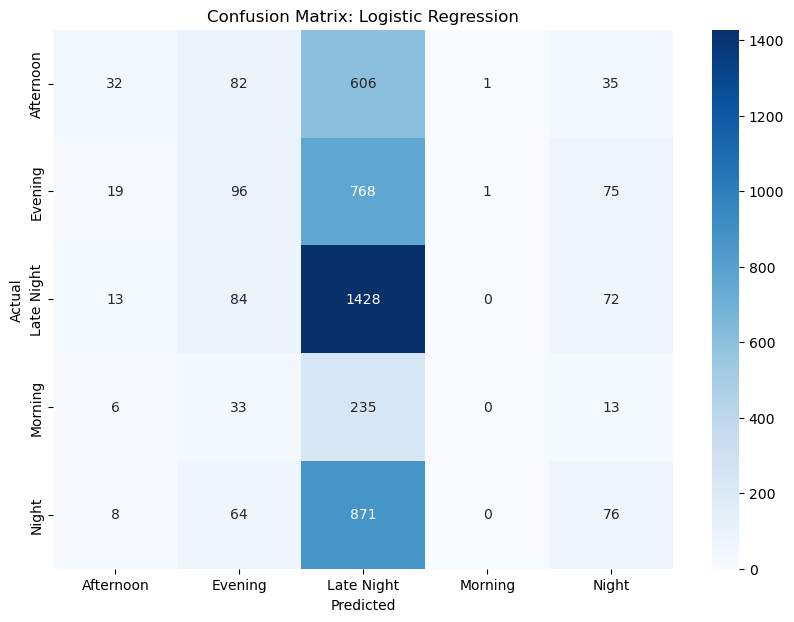

In [434]:
plt.figure(figsize = (10,7))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues', xticklabels = le.classes_, yticklabels = le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Logistic Regression')
plt.show()

In [438]:
#RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators = 200, random_state = 42)
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [439]:
predictions = rf.predict(X_test)
print('Predictions:', predictions)

Predictions: [2 2 2 ... 2 2 2]


In [440]:
y_pred_rf = rf.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy_rf:.2%}")

Model Accuracy: 35.34%


In [441]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Get the predictions
y_pred_rf = rf.predict(X_test)

# 2. Calculate the Accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf:.2%}")

# 3. Get the detailed report (Precision, Recall, F1)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

Random Forest Accuracy: 35.88%

Classification Report:
              precision    recall  f1-score   support

   Afternoon       0.30      0.12      0.17       756
     Evening       0.34      0.15      0.21       959
  Late Night       0.39      0.80      0.52      1597
     Morning       0.19      0.03      0.05       287
       Night       0.26      0.14      0.18      1019

    accuracy                           0.36      4618
   macro avg       0.29      0.25      0.23      4618
weighted avg       0.32      0.36      0.29      4618



***Other predictor and target variable***     **Just for experimentation**

In [455]:
# 1. Prepare Target (y) - Manual mapping ensures 'Y' is our '1' class
y = complete_df['STAT_MURDER_FLG'].map({'Y': 1, 'N': 0})

# 2. Prepare Features (X) - Selecting the key indicators
feature_cols = ['BORO', 'VICTIM_AGE_GROUP', 'VICTIM_SEX', 'VICTIM_RACE', 'TIME_OF_DAY']
X = pd.get_dummies(complete_df[feature_cols], drop_first=True)

# 3. Split the Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Initialize and Train the Random Forest
# We use class_weight='balanced' to help the model not ignore the fatal cases
rf_model = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

# 5. Predictions and Evaluation
y_pred = rf_model.predict(X_test)

print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 56.99%

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.57      0.68      3763
           1       0.23      0.56      0.33       855

    accuracy                           0.57      4618
   macro avg       0.54      0.57      0.51      4618
weighted avg       0.74      0.57      0.62      4618



Severity Model Accuracy: 56.99%

Detailed Severity Report:
              precision    recall  f1-score   support

           0       0.85      0.57      0.68      3763
           1       0.23      0.56      0.33       855

    accuracy                           0.57      4618
   macro avg       0.54      0.57      0.51      4618
weighted avg       0.74      0.57      0.62      4618



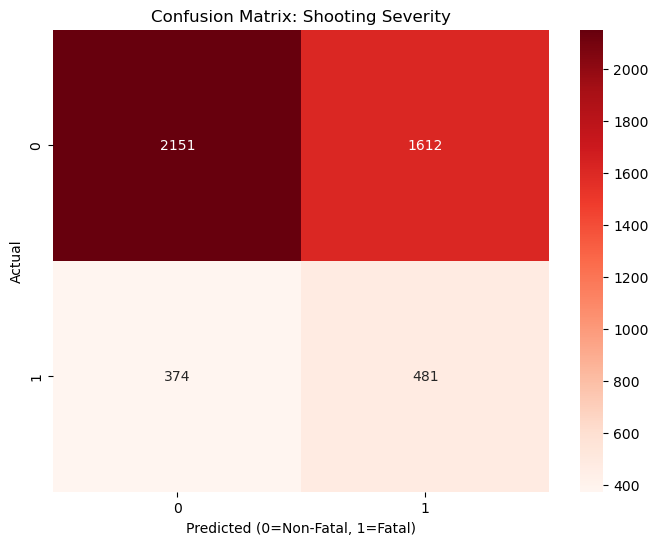

In [456]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Generate predictions using the severity model (rf_model)
y_pred_sev = rf_model.predict(X_test)

# 2. Output the basic Accuracy Score
accuracy_sev = accuracy_score(y_test, y_pred_sev)
print(f"Severity Model Accuracy: {accuracy_sev:.2%}")

# 3. Output the detailed Classification Report
# This shows Precision/Recall for 0 (Non-Fatal) and 1 (Fatal)
print("\nDetailed Severity Report:")
print(classification_report(y_test, y_pred_sev))

# 4. Visualize the Confusion Matrix
cm_sev = confusion_matrix(y_test, y_pred_sev)
plt.figure(figsize=(8,6))
sns.heatmap(cm_sev, annot=True, fmt='d', cmap='Reds')
plt.title('Confusion Matrix: Shooting Severity')
plt.xlabel('Predicted (0=Non-Fatal, 1=Fatal)')
plt.ylabel('Actual')
plt.show()

/var/folders/24/13s3h00j00s83zlgq_331snw0000gn/T/ipykernel_1383/611524253.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=complete_df, x='BORO', ax=axes[0, 0],
/var/folders/24/13s3h00j00s83zlgq_331snw0000gn/T/ipykernel_1383/611524253.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=complete_df, x='TIME_OF_DAY', ax=axes[0, 1],
/var/folders/24/13s3h00j00s83zlgq_331snw0000gn/T/ipykernel_1383/611524253.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=complete_df, x='STAT_MURDER_FLG', ax=axes[1, 0], palette='cool

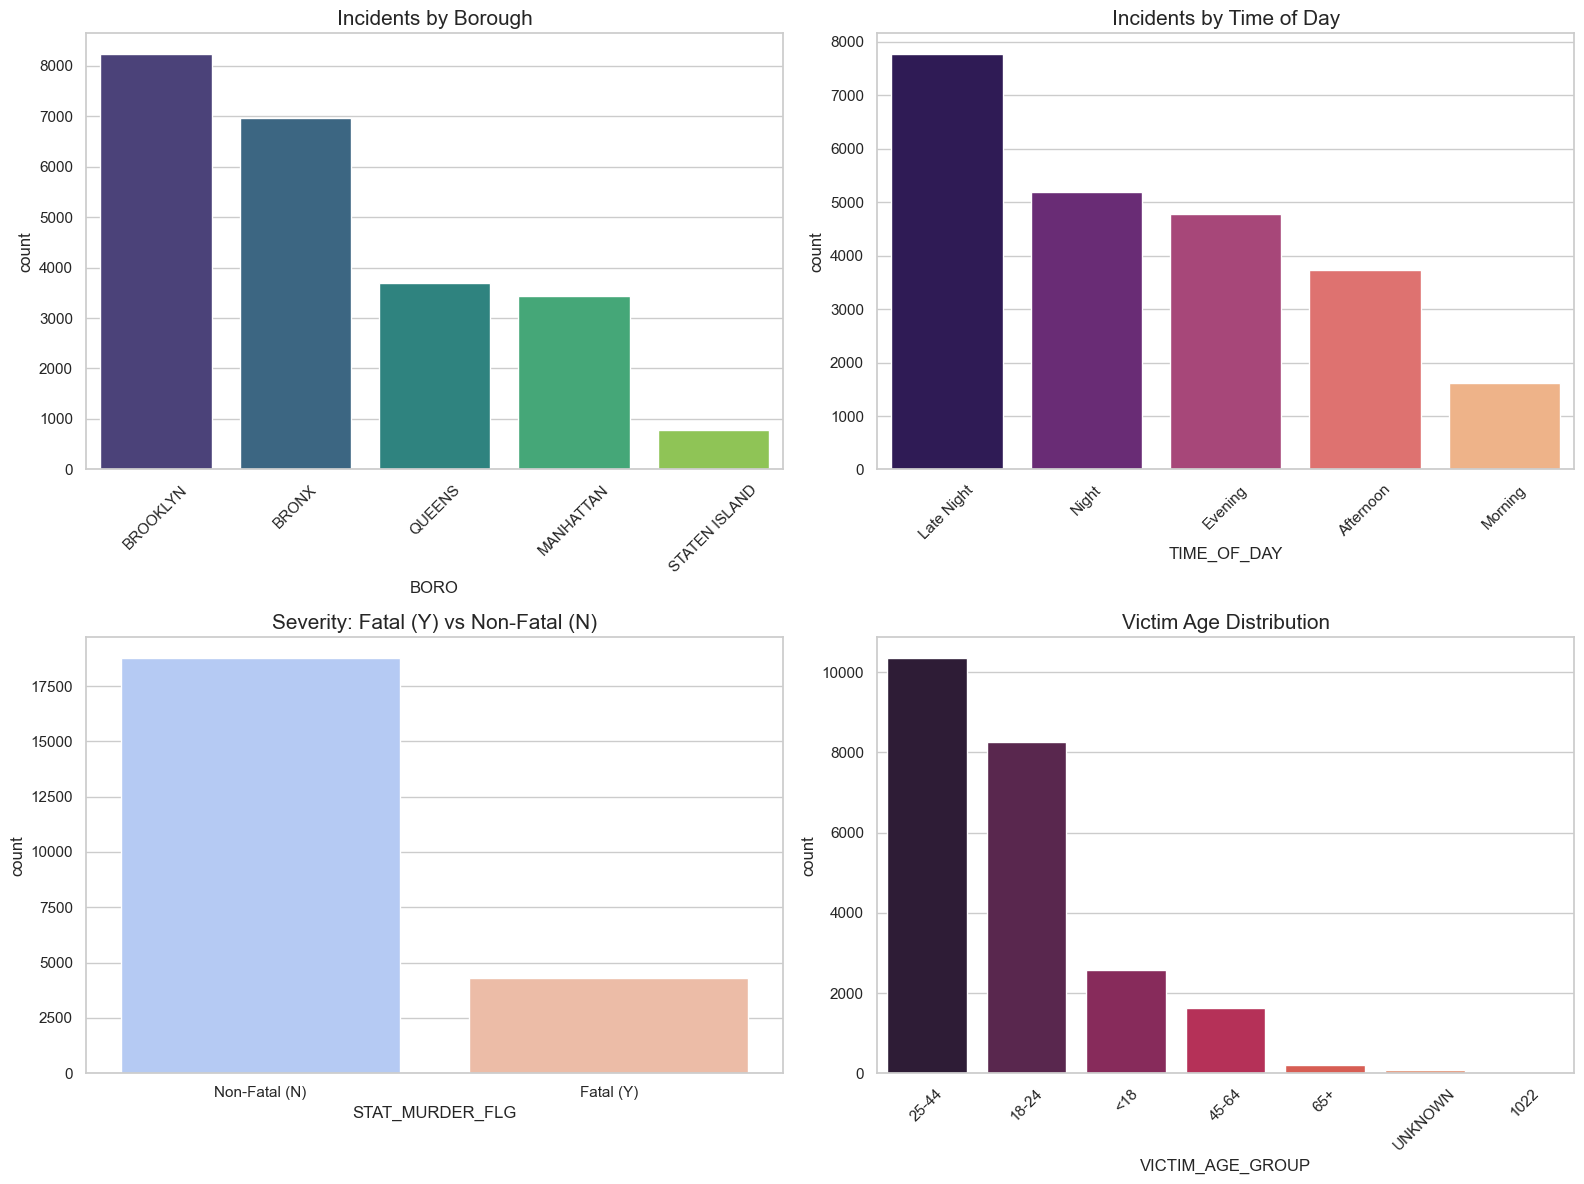

In [458]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style
sns.set_theme(style="whitegrid")

# Create a figure with 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Distribution of Shootings by Borough (Sorted)
sns.countplot(data=complete_df, x='BORO', ax=axes[0, 0], 
              order=complete_df['BORO'].value_counts().index, palette='viridis')
axes[0, 0].set_title('Incidents by Borough', fontsize=15)
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Distribution by Time of Day (Sorted)
sns.countplot(data=complete_df, x='TIME_OF_DAY', ax=axes[0, 1], 
              order=complete_df['TIME_OF_DAY'].value_counts().index, palette='magma')
axes[0, 1].set_title('Incidents by Time of Day', fontsize=15)
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Shooting Severity (Target Variable)
sns.countplot(data=complete_df, x='STAT_MURDER_FLG', ax=axes[1, 0], palette='coolwarm')
axes[1, 0].set_title('Severity: Fatal (Y) vs Non-Fatal (N)', fontsize=15)
axes[1, 0].set_xticklabels(['Non-Fatal (N)', 'Fatal (Y)'])

# 4. Victim Age Group
sns.countplot(data=complete_df, x='VICTIM_AGE_GROUP', ax=axes[1, 1], 
              order=complete_df['VICTIM_AGE_GROUP'].value_counts().index, palette='rocket')
axes[1, 1].set_title('Victim Age Distribution', fontsize=15)
axes[1, 1].tick_params(axis='x', rotation=45)

# Adjust layout to prevent label truncation
plt.tight_layout()
plt.show()